<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Exploration of soil moisture for cells in different HC classes
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p><strong>Each grid cell in the UK is classified according to its hydraulic conductivity.</strong></p>
   <ul>      
        <li> **Low HC**: very impermeable soils (e.g., clay) </li>
        <li> **Medium HC**: moderately permeable soils (e.g., loam) </li>
        <li> **High HC**: very permeable soils (e.g., sand/gravel) </li>
        </ul>

  <p><strong>Why am I doing this?:</strong></p>
  <ul>
    <li> In AnalyseResults.ipynb compare the antecedent conditions of events happening on clay vs. sandy soils </li>
    <li> Want to know whether those differences are to do with something about the events themselves or just to do with the antecedent conditions on those soils </li>
  </ul>    
    
    
  <p><strong>This script tests:</strong></p>
  <ul>
<!--     <li>The number of events per catchment, per ensemble member with an unphysical value</li>
    <li>The number of pixels affected per event</li> -->
  </ul>

</div>

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm
from affine import Affine
from rasterstats import zonal_stats
import xarray as xr

ENSEMBLE_MEMBERS = ['01', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '15']

SOIL_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/soil_texture/"
CATCHMENT_DIR = "/scratch/hydro4/users/kv25483/FutureFlood/Data/CatchmentShapefiles/"
catchments = gpd.read_file(CATCHMENT_DIR + "hyd_areas_GB_with_subcatchments.shp")

In [8]:
regions_shp = "/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/#ss/plots/most_exposed_events_visualisation/by_region/ukcp18-uk-land-region-hires.shp"
regions_df = gpd.read_file(regions_shp)

### Join together the Hydraulic Conductivity data for each catchment - one file for whole country

In [92]:
national_cube = xr.load_dataset("/scratch/hydro4/users/kv25483/FutureFlood/Data/SoilStaticVariables/Mean_HydraulicConductivity_GB_5km.nc")
# national_cube["aggregated_mean"] = national_cube["aggregated_mean"].transpose(
#     "projection_y_coordinate",
#     "projection_x_coordinate")

### Plot spatially
Plot raw values with log scaling (NB: Raw values here means the mean HC value across a 5km grid cell, based on values at 30m)

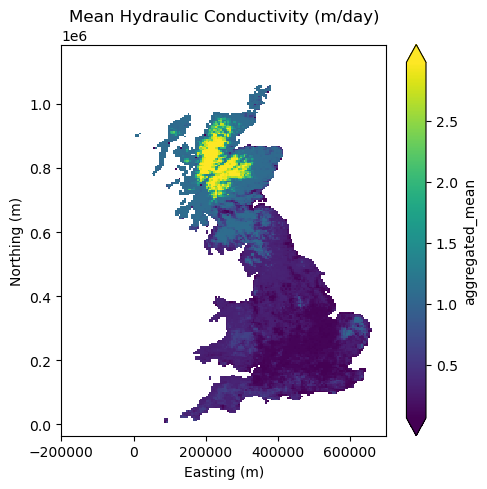

In [93]:
fig, ax = plt.subplots(figsize=(5, 5))

national_cube["aggregated_mean"].plot(ax=ax,cmap="viridis",robust=True) #sets color limits based on 2nd and 98th percentiles

ax.set_title("Mean Hydraulic Conductivity (m/day)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()

### Convert into 3 classes (based on equal numbers in each)

In [94]:
data = national_cube["aggregated_mean"]

# Get data
hk_vals = data.values

# Convert masked values to np.nan if necessary
if np.ma.is_masked(hk_vals):
    hk_vals = hk_vals.filled(np.nan)

# Define class boundaries
q1, q2 = np.nanquantile(hk_vals, [1/3, 2/3])

# Convert data to classes
classified = np.digitize(hk_vals,bins=[q1, q2]).astype(float)

# Preserve NaNs
classified[np.isnan(hk_vals)] = np.nan

print(q1, q2)

# Convert back to xarray, retaining spatial dimensions/coordinates
hc_class_cube = xr.DataArray(classified,dims=data.dims,coords=data.coords,name="HC_class")

0.28016645711360577 0.6898490909316768


### Convert into 3 classes (based on HC values - GA version)

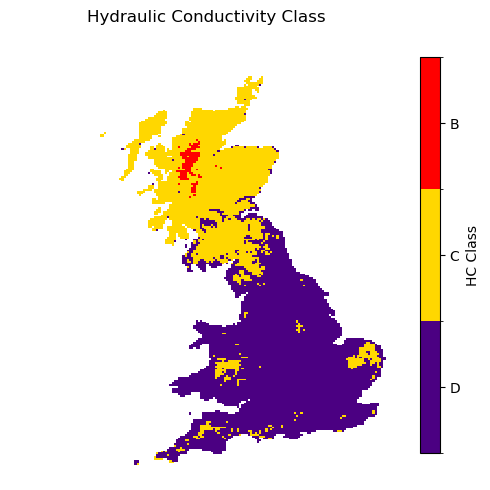

In [95]:
data = national_cube["aggregated_mean"]

# Get data
hk_vals = data.values

# Convert masked values to np.nan if necessary
if np.ma.is_masked(hk_vals):
    hk_vals = hk_vals.filled(np.nan)

# Define class boundaries
q1, q2 = 0.5, 3

# Convert data to classes: 0, 1, 2
classified = np.digitize(hk_vals,bins=[q1, q2]).astype(float)

# Preserve NaNs
classified[np.isnan(hk_vals)] = np.nan

# Convert back to xarray
hc_class_cube = xr.DataArray(classified,dims=data.dims,coords=data.coords,name="HC_class")

# -------------------------
# Plot
# -------------------------

class_labels = ['D', 'C', 'B']
colors = ['indigo', 'gold', 'red']

cmap = ListedColormap(colors)

# Boundaries for classes 0, 1, 2
norm = BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5],ncolors=3)

fig, ax = plt.subplots(figsize=(5, 5))

mesh = hc_class_cube.plot.pcolormesh(ax=ax,cmap=cmap, norm=norm,add_colorbar=False)

ax.set_title("Hydraulic Conductivity Class")
ax.set_axis_off()

# Discrete colourbar
cbar = fig.colorbar(mesh,ax=ax,orientation="vertical",fraction=0.046,pad=0.04,ticks=[0, 1, 2])

cbar.ax.set_yticklabels(class_labels)
cbar.set_label("HC Class")

plt.tight_layout()
plt.show()

In [105]:
# Get data
data = national_cube["aggregated_mean"]
# Get data
hk_vals = data.values

# Convert masked values to np.nan
if np.ma.is_masked(hk_vals):
    hk_vals = hk_vals.filled(np.nan)
    
# Define class boundaries
q1, q2, q3  = 0.15, 1.1, 3

# Convert data to classes
classified = np.digitize(hk_vals, bins=[q1, q2, q3]).astype(float)
classified[np.isnan(hk_vals)] = np.nan

hc_class_cube = xr.DataArray(classified,dims=data.dims,coords=data.coords,name="HC_class")

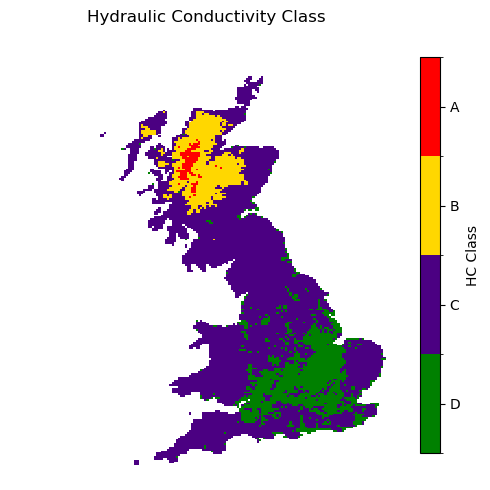

In [109]:
# Get data
data = national_cube["aggregated_mean"]
# Get data
hk_vals = data.values

# Convert masked values to np.nan
if np.ma.is_masked(hk_vals):
    hk_vals = hk_vals.filled(np.nan)
    
# Define class boundaries
q1, q2, q3  = 0.15, 1.1, 3

# Convert data to classes
classified = np.digitize(hk_vals, bins=[q1, q2, q3]).astype(float)
classified[np.isnan(hk_vals)] = np.nan

hc_class_cube = xr.DataArray(classified,dims=data.dims,coords=data.coords,name="HC_class")

# -------------------------
# Plot
# -------------------------

class_labels = ['D', 'C', 'B', 'A']
colors = ['green','indigo', 'gold', 'red']

cmap = ListedColormap(colors)

# Boundaries for classes 0, 1, 2
norm = BoundaryNorm(
    boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5],
    ncolors=4)

fig, ax = plt.subplots(figsize=(5, 5))

mesh = hc_class_cube.plot.pcolormesh(ax=ax,cmap=cmap, norm=norm,add_colorbar=False)

ax.set_title("Hydraulic Conductivity Class")
ax.set_axis_off()

# Discrete colourbar
cbar = fig.colorbar(mesh,ax=ax,orientation="vertical",fraction=0.046,pad=0.04,ticks=[0, 1, 2, 3])

cbar.ax.set_yticklabels(class_labels)
cbar.set_label("HC Class")

plt.tight_layout()
plt.show()

### Find the mean HC in each region

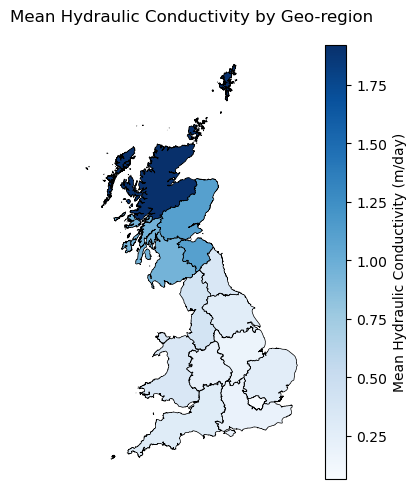

In [9]:
# Extract data and coordinates from the cube
hc_data = national_cube.data  # shape (244, 180)

y_coord = national_cube.coord('projection_y_coordinate').points
x_coord = national_cube.coord('projection_x_coordinate').points

# Resolution (assumes regular grid spacing, true for UKCP18/OSGB grids)
res_x = x_coord[1] - x_coord[0]
res_y = y_coord[1] - y_coord[0]

# Iris coords are usually ascending in y; rasterio/affine expects the
# transform's origin at the top-left, with a *negative* y-resolution.
# So if y_coord is ascending, flip the data vertically to match.
if y_coord[1] > y_coord[0]:
    hc_data = np.flipud(hc_data)
    top_left_y = y_coord[-1] + res_y / 2
else:
    top_left_y = y_coord[0] + res_y / 2

top_left_x = x_coord[0] - res_x / 2

transform = Affine(res_x, 0, top_left_x,
                    0, -abs(res_y), top_left_y)

if regions_df.crs is None:
    regions_df = regions_df.set_crs(epsg=27700)  # set if you know it's already BNG
else:
    regions_df = regions_df.to_crs(epsg=27700)
    
stats = zonal_stats(regions_df,hc_data,affine=transform,stat=['mean'],nodata=np.nan,geojson_out=False)

regions_df['mean_HC'] = [s['mean'] for s in stats]    

fig, ax = plt.subplots(figsize=(4, 5))

regions_df.plot( column='mean_HC', cmap='Blues', legend=True, edgecolor='black', linewidth=0.5, ax=ax, 
                legend_kwds={'label': 'Mean Hydraulic Conductivity (m/day)'})

ax.set_title('Mean Hydraulic Conductivity by Geo-region')
ax.set_axis_off()
plt.tight_layout()
plt.show()